<a href="https://colab.research.google.com/github/If-Spectre21/3d-printing-service-db/blob/main/Multiple_Linear_Regression_Ian_Hermie_Fidelo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# User input
ac_input = float(input('Enter AC usage hours per day: '))
appliance_input = int(input('Enter number of appliances used: '))
house_input = float(input('Enter house size in square meters: '))

# Convert to dataframe
user_data = pd.DataFrame({
    'AC_Usage_Hours': [ac_input],
    'Number_of_Appliances': [appliance_input],
    'House_Size_sqm': [house_input]
})

# Predict
predicted_bill = model.predict(user_data)

print(f'Estimated Monthly Electricity Bill: PHP {predicted_bill[0]:.2f}')

Enter AC usage hours per day: 8
Enter number of appliances used: 10
Enter house size in square meters: 120
Estimated Monthly Electricity Bill: PHP 8406.75


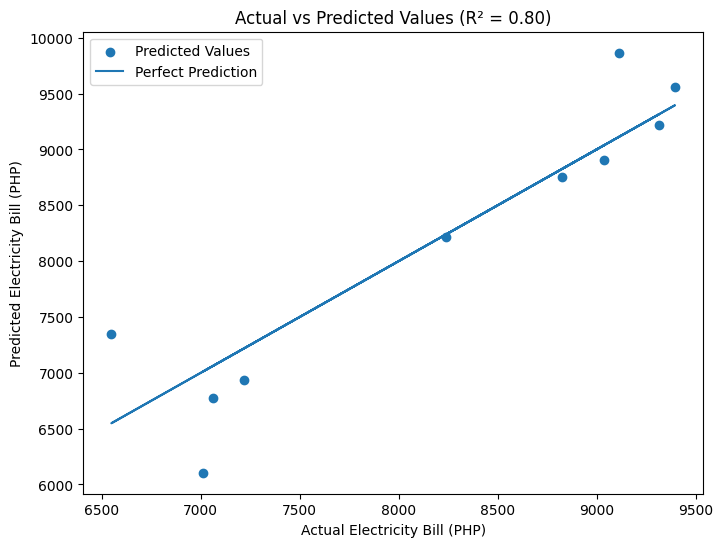

In [9]:
plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(y_test, predictions, label='Predicted Values')

# Perfect prediction line
plt.plot(y_test, y_test, label='Perfect Prediction')

# Labels
plt.xlabel('Actual Electricity Bill (PHP)')
plt.ylabel('Predicted Electricity Bill (PHP)')

# Title
plt.title(f'Actual vs Predicted Values (R² = {r2:.2f})')

plt.legend()

plt.show()

In [8]:
# Predictions
predictions = model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 225361.6460016442
R2 Score: 0.7950222234528643


In [7]:
# Intercept
print("Intercept:")
print(model.intercept_)

# Coefficients
coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Slope/Coefficient': model.coef_
})

print(coefficients)

Intercept:
1352.2139691586035
               Variable  Slope/Coefficient
0        AC_Usage_Hours         452.942512
1  Number_of_Appliances         148.702993
2        House_Size_sqm          16.199736


In [6]:
# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


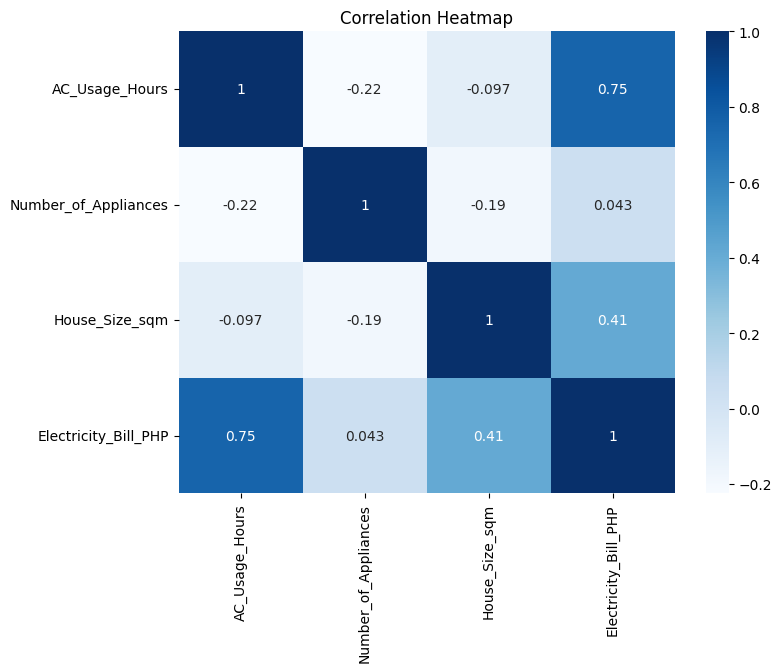

In [4]:
# Correlation matrix
correlation = df.corr()

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap='Blues')

plt.title('Correlation Heatmap')

plt.show()

In [3]:
# Independent variables
X = df[['AC_Usage_Hours', 'Number_of_Appliances', 'House_Size_sqm']]

# Dependent variable
y = df['Electricity_Bill_PHP']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.head())
print(y_train.head())

    AC_Usage_Hours  Number_of_Appliances  House_Size_sqm
12              11                    10              62
4                8                     9              34
37              11                    15              44
8               10                     4             230
3               11                    11             152
12     9243
4      7509
37    10399
8     10573
3     10772
Name: Electricity_Bill_PHP, dtype: int64


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv('electricity_bill_dataset.csv')

print(df.head())

   AC_Usage_Hours  Number_of_Appliances  House_Size_sqm  Electricity_Bill_PHP
0               7                     5             192                  7670
1               4                     7             192                  7079
2              13                     9              62                  9543
3              11                    11             152                 10772
4               8                     9              34                  7509


In [1]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Generate random data
rows = 50

ac_usage = np.random.randint(1, 15, rows)  # hours/day
appliances = np.random.randint(3, 20, rows)  # number of appliances
house_size = np.random.randint(30, 250, rows)  # square meters

# Generate electricity bill with positive correlation
bill = (
    ac_usage * 450 +
    appliances * 120 +
    house_size * 15 +
    np.random.randint(500, 3000, rows)
)

# Create dataframe

df = pd.DataFrame({
    'AC_Usage_Hours': ac_usage,
    'Number_of_Appliances': appliances,
    'House_Size_sqm': house_size,
    'Electricity_Bill_PHP': bill
})

# Save CSV file

df.to_csv('electricity_bill_dataset.csv', index=False)

# Display dataset
print(df.head())

   AC_Usage_Hours  Number_of_Appliances  House_Size_sqm  Electricity_Bill_PHP
0               7                     5             192                  7670
1               4                     7             192                  7079
2              13                     9              62                  9543
3              11                    11             152                 10772
4               8                     9              34                  7509
